### The Vanishing Market: How the Inflation Reduction Act Disrupted Medicare Drug Coverage

Regression analysis of the changes in Medicare's Prescription Drug Plans availability

Luiza Swierzawska, Columbia Journalism School, Spring 2026


In [1]:
# Import packages

import pandas as pd
%load_ext rpy2.ipython

Error importing in API mode: ImportError("dlopen(/Users/luizaswierzawska1/.pyenv/versions/3.13.9/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <B96A8100-FA7A-3EFC-8726-931D26646DE6> /Users/luizaswierzawska1/.pyenv/versions/3.13.9/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


In [2]:
%%R
# Import packages for visualization in R

library(tidyverse)
library(tigris)
library(sf)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


To enable caching of data, set `options(tigris_use_cache = TRUE)`
in your R script or .Rprofile.
Linking to GEOS 3.14.1, GDAL 3.12.2, PROJ 9.7.1; sf_use_s2() is TRUE


In [19]:
# Experts have criticized IRA for causing PDPs to diminish. For this reason, the analysis compares the latest 2026 CMS data with the year 2022 when IRA was passed. 

df_2022_pdp = pd.read_csv("2022LandscapeSource file PDP 10262021.csv", header=3)
df_2022_pdp = df_2022_pdp.dropna(how='all') # While reading it for the first time, I've noticed the end of the column was just NAs
df_2022_pdp

# This dataset includes only PDPs. For 2022, information on other plan types is in separate files. 

,State,Organization Name,Plan Name,Benefit Type,$0 Premium with \nFull Low-Income Subsidy?,Monthly Drug Premium,Annual Drug Deductible,Additional Drug Coverage Offered in the Gap,Contract ID,Plan ID,Benefit Type Detail,Summary Star Rating,Unnamed: 12
0,Alabama,Aetna Medicare,SilverScript Choice (PDP),Basic,x,$29.70,$480.00,No,S5601,24.0,BA,3.5,NaN
1,Alabama,Aetna Medicare,SilverScript Plus (PDP),Enhanced,NaN,$54.80,$0.00,Yes,S5601,25.0,EA,3.5,NaN
2,Alabama,Aetna Medicare,SilverScript SmartRx (PDP),Enhanced,NaN,$6.50,$480.00,No,S5601,187.0,EA,3.5,NaN
3,Alabama,Blue Cross and Blue Shield of Alabama,BlueRx Enhanced (PDP),Enhanced,NaN,$88.60,$480.00,No,S1030,10.0,EA,3.5,NaN
4,Alabama,Blue Cross and Blue Shield of Alabama,BlueRx Enhanced Plus (PDP),Enhanced,NaN,$144.10,$0.00,No,S1030,1.0,EA,3.5,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1148,Wyoming,UnitedHealthcare,AARP MedicareRx Saver Plus (PDP),Basic,x,$36.20,$480.00,No,S5921,370.0,AE,4,NaN
1149,Wyoming,UnitedHealthcare,AARP MedicareRx Walgreens (PDP),Enhanced,NaN,$29.30,$310.00,No,S5921,406.0,EA,4,NaN
1150,Wyoming,Wellcare,Wellcare Classic (PDP),Basic,x,$32.90,$480.00,No,S4802,89.0,AE,3.5,NaN
1151,Wyoming,Wellcare,Wellcare Medicare Rx Value Plus (PDP),Enhanced,NaN,$68.90,$0.00,No,S4802,228.0,EA,3.5,NaN


In [4]:
# Inspecting the dataset

print(df_2022_pdp.columns)
print(df_2022_pdp.shape)

# While the number of rows suggests there are 1153 PDPs, it's the same case as in the previous dataset — one plan is represented by mutiple rows due to 
# different segment IDs. 
# When we group them by their unique identificators Contract ID + Plan ID, we end up with 776 plans which is compatible with the information from external resources, 
# such as KFF: https://www.kff.org/medicare/medicare-part-d-a-first-look-at-medicare-prescription-drug-plans-in-2022/. 

Index(['State', 'Organization Name', 'Plan Name', 'Benefit Type',
       '$0 Premium with \nFull Low-Income Subsidy?', 'Monthly Drug Premium',
       'Annual Drug Deductible', 'Additional Drug Coverage Offered in the Gap',
       'Contract ID', 'Plan ID', 'Benefit Type Detail', 'Summary Star Rating',
       'Unnamed: 12'],
      dtype='object')
(1153, 13)


In [5]:
# Minimum Story focuses on the number of plans available. In the interview with Jennifer Snow, she pointed out how certain states tend to suffer more than others. 
# The linear regression allows for testing whether certain states' characteristics -- whether it's the demographics or socioeconomics -- are affected disproportionately more. 

# Number of plans in 2022 amounted to 776. But what was the distribution of these plans on a state level? 


df_2022_pdp["ContractPlanID"] = df_2022_pdp["Contract ID"] + "-" + df_2022_pdp["Plan ID"].astype(str)

plans_2022 = (
      df_2022_pdp
      .groupby("State")["ContractPlanID"]
      .nunique()
      .reset_index()
      .rename(columns={"State": "State Name", "ContractPlanID": "plans_2022"})
      )

print(plans_2022["plans_2022"].sum())
plans_2022

1153


,State Name,plans_2022
0,Alabama,26
1,Alaska,20
2,American Samoa,1
3,Arizona,27
4,Arkansas,23
5,California,25
6,Colorado,20
7,Connecticut,21
8,Delaware,21
9,Florida,22


In [6]:
# Loading the dataset for 2026 to compare the current PDP market with pre-IRA times

df_2026 = pd.read_csv("CY2026_Landscape_202603.csv")
pd.set_option('display.max_columns', None)
df_2026

,Contract Year,Contract Category Type,US Territory,State Territory Abbreviation,State Territory Name,County Name,Contract ID,Plan ID,Segment ID,ContractPlanID,ContractPlanSegmentID,Sanctioned Plan,Parent Organization Name,Contract Name,Organization Marketing Name,Organization Type,Plan Name,Plan Type,Special Needs Plan (SNP) Indicator,SNP Type,SNP Institutional Type,SNP Institutional Category,Dual Eligible SNP (D-SNP) Integration Status,D-SNP Applicable Integrated Plan (AIP) Identifier,Chronic or Disabling Condition SNP (C-SNP) Condition Type,Medicare Zero-Dollar Cost Sharing D-SNP Plan,Part D Coverage Indicator,National PDP,Drug Benefit Category,Drug Benefit Type,Voluntary De Minimis Program Participant,Part D Basic Premium At or Below Regional Benchmark,Low Income Subsidy (LIS) Auto Enrollment,Offers Drug Tier with No Part D Deductible,Annual Part D Deductible Amount,Part D Basic Premium,Part D Supplemental Premium,Part D Total Premium,Low Income Premium Subsidy (LIPS) Amount,Part D LIPS (CMS Pays),Part D Low Income Beneficiary Premium Amount,Part D Out-of-Pocket (OOP) Threshold,Part C Premium,Monthly Consolidated Premium (Part C + D),In-Network Maximum Out-of-Pocket (MOOP) Amount,Part C Summary Star Rating,Part D Summary Star Rating,Overall Star Rating,MA Region Code,MA Region,PDP Region Code,PDP Region
0,2026,PDP,No,AK,Alaska,All Counties,S4802,96,0,S4802_096,S4802_096_0,No,Centene Corporation,"WELLCARE PRESCRIPTION INSURANCE, INC.",Wellcare,Medicare Prescription Drug Plan,Wellcare Classic (PDP),PDP,No,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Yes,Yes,Basic,Actuarially Equivalent Standard,No,Yes,Yes,Not Applicable,$615.00,$0.00,$0.00,$0.00,$0.00,$0.00,$0.00,"$2,100.00",Not Applicable,Not Applicable,Not Applicable,Not Applicable,3.5,Not Applicable,Not Applicable,Not Applicable,34,Alaska
1,2026,PDP,No,AK,Alaska,All Counties,S4802,165,0,S4802_165,S4802_165_0,No,Centene Corporation,"WELLCARE PRESCRIPTION INSURANCE, INC.",Wellcare,Medicare Prescription Drug Plan,Wellcare Value Script (PDP),PDP,No,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Yes,Yes,Enhanced,Enhanced Alternative,No,Not Applicable,Not Applicable,Yes,$615.00,($3.90),$23.60,$19.70,$0.00,$0.00,$19.70,"$2,100.00",Not Applicable,Not Applicable,Not Applicable,Not Applicable,3.5,Not Applicable,Not Applicable,Not Applicable,34,Alaska
2,2026,PDP,No,AK,Alaska,All Counties,S5601,68,0,S5601_068,S5601_068_0,No,CVS Health Corporation,SILVERSCRIPT INSURANCE COMPANY,Aetna Medicare,Medicare Prescription Drug Plan,SilverScript Choice (PDP),PDP,No,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Yes,No,Basic,Actuarially Equivalent Standard,No,No,Not Applicable,Not Applicable,$615.00,$94.90,$0.00,$94.90,$0.00,$0.00,$94.90,"$2,100.00",Not Applicable,Not Applicable,Not Applicable,Not Applicable,3.0,Not Applicable,Not Applicable,Not Applicable,34,Alaska
3,2026,PDP,No,AK,Alaska,All Counties,S5617,227,0,S5617_227,S5617_227_0,No,Health Care Service Corporation,MEDCO CONTAINMENT LIFE AND MEDCO CONTAINMENT NY,HealthSpring,Medicare Prescription Drug Plan,HealthSpring Assurance Rx (PDP),PDP,No,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Yes,No,Basic,Actuarially Equivalent Standard,No,Yes,Yes,Not Applicable,$615.00,$0.00,$0.00,$0.00,$0.00,$0.00,$0.00,"$2,100.00",Not Applicable,Not Applicable,Not Applicable,Not Applicable,2.5,Not Applicable,Not Applicable,Not Applicable,34,Alaska
4,2026,PDP,No,AK,Alaska,All Counties,S5884,116,0,S5884_116,S5884_116_0,No,Humana Inc.,Humana Insurance Co. & Humana Insurance Co. of NY,Humana,Medicare Prescription Drug Plan,Humana Basic Rx Plan (PDP),PDP,No,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Not Applicable,Yes,Yes,Basic,Actuarially Equivalent Standard,No,Yes,Yes,Not Applicable,

In [7]:
# Inspecting the dataset

print(df_2026.columns)
print(df_2026.shape)

Index(['Contract Year', 'Contract Category Type', 'US Territory',
       'State Territory Abbreviation', 'State Territory Name', 'County Name',
       'Contract ID', 'Plan ID', 'Segment ID', 'ContractPlanID',
       'ContractPlanSegmentID', 'Sanctioned Plan', 'Parent Organization Name',
       'Contract Name', 'Organization Marketing Name', 'Organization Type',
       'Plan Name', 'Plan Type', 'Special Needs Plan (SNP) Indicator',
       'SNP Type', 'SNP Institutional Type', 'SNP Institutional Category',
       'Dual Eligible SNP (D-SNP) Integration Status',
       'D-SNP Applicable Integrated Plan (AIP) Identifier',
       'Chronic or Disabling Condition SNP (C-SNP) Condition Type',
       'Medicare Zero-Dollar Cost Sharing D-SNP Plan',
       'Part D Coverage Indicator', 'National PDP', 'Drug Benefit Category',
       'Drug Benefit Type', 'Voluntary De Minimis Program Participant',
       'Part D Basic Premium At or Below Regional Benchmark',
       'Low Income Subsidy (LIS) Auto Enr

In [8]:
# Inspecting plan and contract types

print(df_2026["Plan Type"].value_counts()) 
print(df_2026["Contract Category Type"].value_counts()) 
print(df_2026[df_2026["Plan Type"] == "PDP"]["ContractPlanSegmentID"].nunique())

# At first, my output was showing 549 PDPs, which was incompatible with external resources. 
# It's because a plan can have multiple segment IDs (geographic subdivisions within a region), so one plan is represented by multiple rows. 

Plan Type
PPO                   45140
HMO-POS               18218
HMO D-SNP             17540
HMO                   14242
HMO-POS D-SNP          9911
PPO D-SNP              8225
Regional PPO           5648
HMO C-SNP              3714
HMO I-SNP              3242
PPO C-SNP              2974
PPO I-SNP              2252
HMO-POS C-SNP          2191
Cost                   1421
PFFS                   1136
Regional PPO C-SNP     1093
PDP                     549
HMO-POS I-SNP           374
Regional PPO D-SNP      321
MSA                      72
Name: count, dtype: int64
Contract Category Type
MA-PD    64249
SNP      51837
MA       20207
Cost      1421
PDP        549
Name: count, dtype: int64
367


In [9]:
# Similarly to 2022 data, this step involves grouping the plans by states to see their distribution 
# and later compute the difference between the number of plans available in 2022 and 2026.

plans_2026 = (
      df_2026[df_2026["Plan Type"] == "PDP"] # Since the analysis focuses on PDPs, the dataset needs to be filtered. 
      .groupby(["State Territory Name", "State Territory Abbreviation"])["ContractPlanID"]
      .nunique()
      .reset_index()
      .rename(columns={
          "State Territory Name": "State Name",
          "State Territory Abbreviation": "State Abbreviation",
          "ContractPlanID": "plans_2026"
      })
  )

print(plans_2026['plans_2026'].sum())
plans_2026

549


,State Name,State Abbreviation,plans_2026
0,Alabama,AL,12
1,Alaska,AK,9
2,American Samoa,AS,1
3,Arizona,AZ,10
4,Arkansas,AR,12
5,California,CA,12
6,Colorado,CO,10
7,Connecticut,CT,11
8,Delaware,DE,10
9,District of Columbia,DC,10


In [10]:
# Merging dataframes on a state-level

plans_diff = plans_2026.merge(plans_2022, how="inner", on="State Name")
plans_diff

,State Name,State Abbreviation,plans_2026,plans_2022
0,Alabama,AL,12,26
1,Alaska,AK,9,20
2,American Samoa,AS,1,1
3,Arizona,AZ,10,27
4,Arkansas,AR,12,23
5,California,CA,12,25
6,Colorado,CO,10,20
7,Connecticut,CT,11,21
8,Delaware,DE,10,21
9,Florida,FL,10,22


In [11]:
# Calculating the difference in plans availability per state between the years 2022 and 2026.

plans_diff["change"] = plans_diff["plans_2026"] - plans_diff["plans_2022"]
plans_diff

,State Name,State Abbreviation,plans_2026,plans_2022,change
0,Alabama,AL,12,26,-14
1,Alaska,AK,9,20,-11
2,American Samoa,AS,1,1,0
3,Arizona,AZ,10,27,-17
4,Arkansas,AR,12,23,-11
5,California,CA,12,25,-13
6,Colorado,CO,10,20,-10
7,Connecticut,CT,11,21,-10
8,Delaware,DE,10,21,-11
9,Florida,FL,10,22,-12


In [12]:
# Is there a clear relationship between the change in number of plans and level of premiums? 

df_2022_pdp["Monthly Drug Premium"] = pd.to_numeric(
      df_2022_pdp["Monthly Drug Premium"].astype(str).str.replace("$", "", regex=False).str.strip(),
      errors="coerce"
  )

avg_premium_2022 = (
      df_2022_pdp.groupby("State")["Monthly Drug Premium"]
      .mean()
      .reset_index()
      .rename(columns={
          "State": "State Name",
          "Monthly Drug Premium": "avg_premium_2022"
      })    
  )


avg_premium_2022

,State Name,avg_premium_2022
0,Alabama,51.069231
1,Alaska,42.280000
2,American Samoa,61.500000
3,Arizona,51.062963
4,Arkansas,46.373913
5,California,55.816000
6,Colorado,51.695000
7,Connecticut,49.633333
8,Delaware,42.533333
9,Florida,53.640909


In [13]:
# Calculating average premiums per state for 2026 to compute the change since 2022. 

df_2026_pdp = df_2026[df_2026["Plan Type"] == "PDP"] 
# The 2026 dataset contains different types of Part D plans so before calculating the average premium, it needs to be filtered.

df_2026_pdp["Part D Total Premium"] = pd.to_numeric(
      df_2026_pdp["Part D Total Premium"].astype(str).str.replace("$", "", regex=False).str.strip(),
      errors="coerce"
  )

avg_premium_2026 = (
      df_2026_pdp.groupby("State Territory Abbreviation")["Part D Total Premium"]
      .mean()
      .reset_index()
      .rename(columns={
          "State Territory Abbreviation": "State Abbreviation",
          "Part D Total Premium": "avg_premium_2026"
      })    
  )


avg_premium_2026

/var/folders/3w/05xwp7qj761gvqj6rcry6n700000gp/T/ipykernel_72697/2981272258.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2026_pdp["Part D Total Premium"] = pd.to_numeric(


,State Abbreviation,avg_premium_2026
0,AK,43.444444
1,AL,66.983333
2,AR,52.841667
3,AS,0.000000
4,AZ,41.920000
5,CA,108.175000
6,CO,70.220000
7,CT,80.345455
8,DC,45.310000
9,DE,45.310000


In [14]:
plans_diff = plans_diff.merge(avg_premium_2026, on="State Abbreviation")
plans_diff = plans_diff.merge(avg_premium_2022, on="State Name")
plans_diff["premium_change"] = plans_diff["avg_premium_2026"] - plans_diff["avg_premium_2022"]
plans_diff

,State Name,State Abbreviation,plans_2026,plans_2022,change,avg_premium_2026,avg_premium_2022,premium_change
0,Alabama,AL,12,26,-14,66.983333,51.069231,15.914103
1,Alaska,AK,9,20,-11,43.444444,42.280000,1.164444
2,American Samoa,AS,1,1,0,0.000000,61.500000,-61.500000
3,Arizona,AZ,10,27,-17,41.920000,51.062963,-9.142963
4,Arkansas,AR,12,23,-11,52.841667,46.373913,6.467754
5,California,CA,12,25,-13,108.175000,55.816000,52.359000
6,Colorado,CO,10,20,-10,70.220000,51.695000,18.525000
7,Connecticut,CT,11,21,-10,80.345455,49.633333,30.712121
8,Delaware,DE,10,21,-11,45.310000,42.533333,2.776667
9,Florida,FL,10,22,-12,86.620000,53.640909,32.979091


In [16]:
# Filtering for US territories since there is limited data on plans available there

territories = ['AS', 'GU', 'MP', 'PR', 'VI']
plans_diff = plans_diff[~plans_diff['State Abbreviation'].isin(territories)]

In [17]:
%%R -i plans_diff
# Model 1: Is there a relationship between the change in the number of plans available per state and the change in average premiums? 

model_1 <- lm(change ~ premium_change, data=plans_diff)
summary(model_1)


Call:
lm(formula = change ~ premium_change, data = plans_diff)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.6231 -1.2801  0.3478  1.0595  2.1202 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)    -12.15093    0.29295  -41.48   <2e-16 ***
premium_change   0.02471    0.01453    1.70   0.0955 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.47 on 48 degrees of freedom
Multiple R-squared:  0.05682,	Adjusted R-squared:  0.03717 
F-statistic: 2.892 on 1 and 48 DF,  p-value: 0.09552



Given the model's intercept (-12.15) the conclusion is that on average states lost about 12 plans regardless of premium changes. This captures the baseline market contraction happening across all states. However, the premium change is not a statistically significant factor in plan loss and most of the shrinkage is driven by other forces. The result became no longer statistically significant after filtering out the US territories. American Samoa, Guam, and Northern Mariana Islands had huge negative premium changes (e.g., AS: -61.5, GU: -45.5) but zero plan change. They were outliers that artificially created a negative relationship between premium change and plan loss.

The analysis above is limited due to the lack of more granular geographical data on the PDPs availability. Unfortunately, these plans are designed on the PDP regions level. One PDP region can encompass multiple states. In total, there are 34 such regions which results in a very small sample. In the model with premium change as a predictor of the change in plan availability the focus was on states since data for premiums is not available on the county level. 

An approach to circumvent this is to focus on the change in enrollment which is available on the county-level.

### Share of Enrollment

Given the geographic constraints, it seems that the change in PDP enrollment is a more compelling research avenue. In that case, the independent variables pertain to the demographics of the enrolless and plan characteristics. It allows for a county-level approach where the number of enrollees in the PDP is the share of all Medicare beneficiaries. 

In [22]:
# Loading the dataset with Medicare enrollment for 2026

df_enrollment_2026 = pd.read_csv("Medicare_Monthly_Enrollment_Jan_2026.csv")
df_enrollment_2026

,YEAR,MONTH,BENE_GEO_LVL,BENE_STATE_ABRVTN,BENE_STATE_DESC,BENE_COUNTY_DESC,BENE_FIPS_CD,TOT_BENES,ORGNL_MDCR_BENES,MA_AND_OTH_BENES,AGED_TOT_BENES,AGED_ESRD_BENES,AGED_NO_ESRD_BENES,DSBLD_TOT_BENES,DSBLD_ESRD_AND_ESRD_ONLY_BENES,DSBLD_NO_ESRD_BENES,MALE_TOT_BENES,FEMALE_TOT_BENES,WHITE_TOT_BENES,BLACK_TOT_BENES,API_TOT_BENES,HSPNC_TOT_BENES,NATIND_TOT_BENES,OTHR_TOT_BENES,AGE_LT_25_BENES,AGE_25_TO_44_BENES,AGE_45_TO_64_BENES,AGE_65_TO_69_BENES,AGE_70_TO_74_BENES,AGE_75_TO_79_BENES,AGE_80_TO_84_BENES,AGE_85_TO_89_BENES,AGE_90_TO_94_BENES,AGE_GT_94_BENES,DUAL_TOT_BENES,FULL_DUAL_TOT_BENES,PART_DUAL_TOT_BENES,NODUAL_TOT_BENES,QMB_ONLY_BENES,QMB_PLUS_BENES,SLMB_ONLY_BENES,SLMB_PLUS_BENES,QDWI_QI_BENES,OTHR_FULL_DUAL_MDCD_BENES,A_B_TOT_BENES,A_B_ORGNL_MDCR_BENES,A_B_MA_AND_OTH_BENES,A_TOT_BENES,A_ORGNL_MDCR_BENES,A_MA_AND_OTH_BENES,B_TOT_BENES,B_ORGNL_MDCR_BENES,B_MA_AND_OTH_BENES,PRSCRPTN_DRUG_TOT_BENES,PRSCRPTN_DRUG_PDP_BENES,PRSCRPTN_DRUG_MAPD_BENES,PRSCRPTN_DRUG_DEEMED_ELIGIBLE_FULL_LIS_BENES,PRSCRPTN_DRUG_FULL_LIS_BENES,PRSCRPTN_DRUG_PARTIAL_LIS_BENES,PRSCRPTN_DRUG_NO_LIS_BENES
0,2026,January,County,AL,Alabama,Autauga County,1001,12322,4772,7550,10365,52,10313,1957,42,1915,5488,6834,9471,2395,84,129,*,*,15,336,1606,2866,2747,2098,1474,745,343,92,2108,744,1364,10214,719,549,407,20,238,175,11361,3813,7548,12261,4713,7548,11422,3872,7550,9120,3433,5687,2141,327,0,6652
1,2026,January,County,AL,Alabama,Baldwin County,1003,66261,27821,38440,60444,172,60272,5817,109,5708,30276,35985,59301,3973,342,1013,106,1526,52,970,4795,14904,16578,13600,8798,4305,1723,536,6857,2079,4778,59404,2500,1371,1483,99,795,609,62087,23658,38429,66127,27695,38432,62221,23784,38437,53797,22358,31439,6926,1068,0,45803
2,2026,January,County,AL,Alabama,Barbour County,1005,6224,1968,4256,5177,47,5130,1047,36,1011,2835,3389,3416,2655,22,31,*,*,*,*,879,1272,1433,1166,771,335,154,46,1848,736,1112,4376,569,520,356,36,187,180,5881,1625,4256,6176,1920,4256,5929,1673,4256,5176,1624,3552,1854,223,0,3099
3,2026,January,County,AL,Alabama,Bibb County,1007,4818,1461,3357,3873,19,3854,945,30,915,2243,2575,3857,837,*,33,*,83,*,*,789,1060,1054,821,519,280,100,39,1117,436,681,3701,336,320,206,25,139,91,4522,1165,3357,4793,1436,3357,4547,1190,3357,3883,1141,2742,1126,209,0,2548
4,2026,January,County,AL,Alabama,Blount County,1009,12463,3966,8497,10691,46,10645,1772,21,1751,5754,6709,11737,201,21,315,*,*,*,*,1495,2638,3014,2379,1542,736,303,79,2079,688,1391,10384,727,495,423,28,241,165,11694,3200,8494,12428,3931,8497,11729,3235,8494,10438,3437,7001,2105,372,0,7961
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3273,2026,January,County,PR,Puerto Rico,Unknown,72999,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*
3274,2026,January,County,VI,Virgin Islands,St. Croix Island,78010,9825,6952,2873,9285,64,9221,540,30,510,4506,5319,1376,6416,71,1597,*,*,*,*,428,1876,2317,2080,1755,809,352,96,199,116,83,9626,62,75,*,*,*,*,8987,6114,2873,9700,6827,2873,9112,6239,2873,5399,4942,457,*,*,0,5246
3275,2026,January,County,VI,Virgin Islands,St. John Island,78020,966,763,203,933,*,*,33,*,*,465,501,405,483,*,39,0,*,0,*,*,222,253,212,158,60,*,*,13,*,*,953,*,*,*,0,0,*,880,677,203,962,759,203,884,681,203,520,480,40,11,0,0,509
3276,2026,January,County,VI,Virgin Islands,St. Thomas Island,78030,9930,6672,3258,9438,74,9364,492,41,451,4542,5388,1385,7491,155,598,*,*,*,*,383,2103,2355,2080,1660,789,339,112,175,92,83,9755,63,59,*,*,*,*,8951,5694,3257,9873,6615,3258,9008,5751,3257,6008,5634,374,*,*,0,5861


In [ ]:
# Inspecting the dataset and checking the format of data used for calculating PDP enrollment share
# Based on available information, the dependent variables needs to be calculated with the following columns: 
# TOT_BENES (count of all Medicare beneficiaries) and PRSCRPTN_DRUG_PDP_BENES (count of Medicare Prescription Drug (or Part D) beneficiaries enrolled in a Prescription Drug Plan)


print(df_enrollment_2026["PRSCRPTN_DRUG_PDP_BENES"].dtype)
print(df_enrollment_2026["TOT_BENES"].dtype)

object
object


In [ ]:
df_enrollment_2026["PRSCRPTN_DRUG_PDP_BENES"] = pd.to_numeric(df_enrollment_2026["PRSCRPTN_DRUG_PDP_BENES"], errors="coerce")
df_enrollment_2026["TOT_BENES"] = pd.to_numeric(df_enrollment_2026["TOT_BENES"], errors="coerce")
df_enrollment_2026["share_of_pdp_enrollment"] = df_enrollment_2026["PRSCRPTN_DRUG_PDP_BENES"]/df_enrollment_2026["TOT_BENES"]
df_enrollment_2026

,YEAR,MONTH,BENE_GEO_LVL,BENE_STATE_ABRVTN,BENE_STATE_DESC,BENE_COUNTY_DESC,BENE_FIPS_CD,TOT_BENES,ORGNL_MDCR_BENES,MA_AND_OTH_BENES,AGED_TOT_BENES,AGED_ESRD_BENES,AGED_NO_ESRD_BENES,DSBLD_TOT_BENES,DSBLD_ESRD_AND_ESRD_ONLY_BENES,DSBLD_NO_ESRD_BENES,MALE_TOT_BENES,FEMALE_TOT_BENES,WHITE_TOT_BENES,BLACK_TOT_BENES,API_TOT_BENES,HSPNC_TOT_BENES,NATIND_TOT_BENES,OTHR_TOT_BENES,AGE_LT_25_BENES,AGE_25_TO_44_BENES,AGE_45_TO_64_BENES,AGE_65_TO_69_BENES,AGE_70_TO_74_BENES,AGE_75_TO_79_BENES,AGE_80_TO_84_BENES,AGE_85_TO_89_BENES,AGE_90_TO_94_BENES,AGE_GT_94_BENES,DUAL_TOT_BENES,FULL_DUAL_TOT_BENES,PART_DUAL_TOT_BENES,NODUAL_TOT_BENES,QMB_ONLY_BENES,QMB_PLUS_BENES,SLMB_ONLY_BENES,SLMB_PLUS_BENES,QDWI_QI_BENES,OTHR_FULL_DUAL_MDCD_BENES,A_B_TOT_BENES,A_B_ORGNL_MDCR_BENES,A_B_MA_AND_OTH_BENES,A_TOT_BENES,A_ORGNL_MDCR_BENES,A_MA_AND_OTH_BENES,B_TOT_BENES,B_ORGNL_MDCR_BENES,B_MA_AND_OTH_BENES,PRSCRPTN_DRUG_TOT_BENES,PRSCRPTN_DRUG_PDP_BENES,PRSCRPTN_DRUG_MAPD_BENES,PRSCRPTN_DRUG_DEEMED_ELIGIBLE_FULL_LIS_BENES,PRSCRPTN_DRUG_FULL_LIS_BENES,PRSCRPTN_DRUG_PARTIAL_LIS_BENES,PRSCRPTN_DRUG_NO_LIS_BENES,share_of_pdp_enrollment
0,2026,January,County,AL,Alabama,Autauga County,1001,12322.0,4772,7550,10365,52,10313,1957,42,1915,5488,6834,9471,2395,84,129,*,*,15,336,1606,2866,2747,2098,1474,745,343,92,2108,744,1364,10214,719,549,407,20,238,175,11361,3813,7548,12261,4713,7548,11422,3872,7550,9120,3433.0,5687,2141,327,0,6652,0.278607
1,2026,January,County,AL,Alabama,Baldwin County,1003,66261.0,27821,38440,60444,172,60272,5817,109,5708,30276,35985,59301,3973,342,1013,106,1526,52,970,4795,14904,16578,13600,8798,4305,1723,536,6857,2079,4778,59404,2500,1371,1483,99,795,609,62087,23658,38429,66127,27695,38432,62221,23784,38437,53797,22358.0,31439,6926,1068,0,45803,0.337423
2,2026,January,County,AL,Alabama,Barbour County,1005,6224.0,1968,4256,5177,47,5130,1047,36,1011,2835,3389,3416,2655,22,31,*,*,*,*,879,1272,1433,1166,771,335,154,46,1848,736,1112,4376,569,520,356,36,187,180,5881,1625,4256,6176,1920,4256,5929,1673,4256,5176,1624.0,3552,1854,223,0,3099,0.260925
3,2026,January,County,AL,Alabama,Bibb County,1007,4818.0,1461,3357,3873,19,3854,945,30,915,2243,2575,3857,837,*,33,*,83,*,*,789,1060,1054,821,519,280,100,39,1117,436,681,3701,336,320,206,25,139,91,4522,1165,3357,4793,1436,3357,4547,1190,3357,3883,1141.0,2742,1126,209,0,2548,0.236820
4,2026,January,County,AL,Alabama,Blount County,1009,12463.0,3966,8497,10691,46,10645,1772,21,1751,5754,6709,11737,201,21,315,*,*,*,*,1495,2638,3014,2379,1542,736,303,79,2079,688,1391,10384,727,495,423,28,241,165,11694,3200,8494,12428,3931,8497,11729,3235,8494,10438,3437.0,7001,2105,372,0,7961,0.275776
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3273,2026,January,County,PR,Puerto Rico,Unknown,72999,NaN,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,*,NaN,*,*,*,*,*,NaN
3274,2026,January,County,VI,Virgin Islands,St. Croix Island,78010,9825.0,6952,2873,9285,64,9221,540,30,510,4506,5319,1376,6416,71,1597,*,*,*,*,428,1876,2317,2080,1755,809,352,96,199,116,83,9626,62,75,*,*,*,*,8987,6114,2873,9700,6827,2873,9112,6239,2873,5399,4942.0,457,*,*,0,5246,0.503003
3275,2026,January,County,VI,Virgin Islands,St. John Island,78020,966.0,763,203,933,*,*,33,*,*,465,501,405,483,*,39,0,*,0,*,*,222,253,212,158,60,*,*,13,*,*,953,*,*,*,0,0,*,880,677,203,962,759,203,884,681,203,520,480.0,40,11,0,0,509,0.496894
3276,2026,January,County,VI,Virgin Islands,St. Thomas Island,78030,9930.0,6672,3258,9438,74,9364,492,41,451,4542,5388,1385,7491,155,598,*,*,*,*,383,2103,2355,2080,1660,789,339,112,175,92,83,9755,63,59,*,*,*,*,8951,5694,3257,9873,6615,3258,9008,5751,3257,6008,5634.0,374,*,*,0,5861,0.567372


In [25]:
# Filtering out US territories due to missing data
territories = ["PR", "VI", "GU", "MP", "AS"]
df_enrollment_2026 = df_enrollment_2026[~df_enrollment_2026["BENE_STATE_ABRVTN"].isin(territories)]
df_enrollment_2026

,YEAR,MONTH,BENE_GEO_LVL,BENE_STATE_ABRVTN,BENE_STATE_DESC,BENE_COUNTY_DESC,BENE_FIPS_CD,TOT_BENES,ORGNL_MDCR_BENES,MA_AND_OTH_BENES,AGED_TOT_BENES,AGED_ESRD_BENES,AGED_NO_ESRD_BENES,DSBLD_TOT_BENES,DSBLD_ESRD_AND_ESRD_ONLY_BENES,DSBLD_NO_ESRD_BENES,MALE_TOT_BENES,FEMALE_TOT_BENES,WHITE_TOT_BENES,BLACK_TOT_BENES,API_TOT_BENES,HSPNC_TOT_BENES,NATIND_TOT_BENES,OTHR_TOT_BENES,AGE_LT_25_BENES,AGE_25_TO_44_BENES,AGE_45_TO_64_BENES,AGE_65_TO_69_BENES,AGE_70_TO_74_BENES,AGE_75_TO_79_BENES,AGE_80_TO_84_BENES,AGE_85_TO_89_BENES,AGE_90_TO_94_BENES,AGE_GT_94_BENES,DUAL_TOT_BENES,FULL_DUAL_TOT_BENES,PART_DUAL_TOT_BENES,NODUAL_TOT_BENES,QMB_ONLY_BENES,QMB_PLUS_BENES,SLMB_ONLY_BENES,SLMB_PLUS_BENES,QDWI_QI_BENES,OTHR_FULL_DUAL_MDCD_BENES,A_B_TOT_BENES,A_B_ORGNL_MDCR_BENES,A_B_MA_AND_OTH_BENES,A_TOT_BENES,A_ORGNL_MDCR_BENES,A_MA_AND_OTH_BENES,B_TOT_BENES,B_ORGNL_MDCR_BENES,B_MA_AND_OTH_BENES,PRSCRPTN_DRUG_TOT_BENES,PRSCRPTN_DRUG_PDP_BENES,PRSCRPTN_DRUG_MAPD_BENES,PRSCRPTN_DRUG_DEEMED_ELIGIBLE_FULL_LIS_BENES,PRSCRPTN_DRUG_FULL_LIS_BENES,PRSCRPTN_DRUG_PARTIAL_LIS_BENES,PRSCRPTN_DRUG_NO_LIS_BENES,share_of_pdp_enrollment
0,2026,January,County,AL,Alabama,Autauga County,1001,12322.0,4772,7550,10365,52,10313,1957,42,1915,5488,6834,9471,2395,84,129,*,*,15,336,1606,2866,2747,2098,1474,745,343,92,2108,744,1364,10214,719,549,407,20,238,175,11361,3813,7548,12261,4713,7548,11422,3872,7550,9120,3433.0,5687,2141,327,0,6652,0.278607
1,2026,January,County,AL,Alabama,Baldwin County,1003,66261.0,27821,38440,60444,172,60272,5817,109,5708,30276,35985,59301,3973,342,1013,106,1526,52,970,4795,14904,16578,13600,8798,4305,1723,536,6857,2079,4778,59404,2500,1371,1483,99,795,609,62087,23658,38429,66127,27695,38432,62221,23784,38437,53797,22358.0,31439,6926,1068,0,45803,0.337423
2,2026,January,County,AL,Alabama,Barbour County,1005,6224.0,1968,4256,5177,47,5130,1047,36,1011,2835,3389,3416,2655,22,31,*,*,*,*,879,1272,1433,1166,771,335,154,46,1848,736,1112,4376,569,520,356,36,187,180,5881,1625,4256,6176,1920,4256,5929,1673,4256,5176,1624.0,3552,1854,223,0,3099,0.260925
3,2026,January,County,AL,Alabama,Bibb County,1007,4818.0,1461,3357,3873,19,3854,945,30,915,2243,2575,3857,837,*,33,*,83,*,*,789,1060,1054,821,519,280,100,39,1117,436,681,3701,336,320,206,25,139,91,4522,1165,3357,4793,1436,3357,4547,1190,3357,3883,1141.0,2742,1126,209,0,2548,0.236820
4,2026,January,County,AL,Alabama,Blount County,1009,12463.0,3966,8497,10691,46,10645,1772,21,1751,5754,6709,11737,201,21,315,*,*,*,*,1495,2638,3014,2379,1542,736,303,79,2079,688,1391,10384,727,495,423,28,241,165,11694,3200,8494,12428,3931,8497,11729,3235,8494,10438,3437.0,7001,2105,372,0,7961,0.275776
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3190,2026,January,County,WY,Wyoming,Teton County,56039,4455.0,4157,298,4374,*,*,81,*,*,2239,2216,4062,*,42,71,*,271,0,34,47,1072,1263,963,631,283,122,40,113,67,46,4342,*,*,20,*,*,31,4131,3834,297,4454,4156,298,4132,3835,297,3424,3236.0,188,115,13,0,3296,0.726375
3191,2026,January,County,WY,Wyoming,Uinta County,56041,4431.0,3323,1108,3961,11,3950,470,14,456,2223,2208,4098,*,13,171,15,*,*,*,361,1116,1292,814,440,195,75,29,472,310,162,3959,92,172,48,35,22,103,4102,2994,1108,4426,3318,1108,4107,2999,1108,3314,2445.0,869,492,51,0,2771,0.551794
3192,2026,January,County,WY,Wyoming,Washakie County,56043,2191.0,1888,303,2044,*,*,147,*,*,1069,1122,1954,0,*,166,*,56,*,*,119,496,551,439,310,149,68,31,213,115,98,1978,56,64,31,*,11,*,2033,1730,303,2188,1885,303,2036,1733,303,1592,1341.0,251,220,18,0,1354,0.612049
3193,2026,January,County,WY,Wyoming,Weston County,56045,1962.0,1723,239,1837,*,*,125,*,*,1013,949,1882,0,*,17,*,51,*,*,98,476,539,371,230,139,59,23,176,91,85,1786,40,*,28,*,17,45,1826,1587,239,1961,1722,239,1827,1588,239,1413,1229.0,184,185,32,0,1196,0.626402


Experts interviewed for this project shared a common concern: as PDP availability shrinks, low-income beneficiaries stand to be hit hardest. At the center of that concern are Low-Income Subsidy benchmark plans — the $0 premium options that this population depends on. Their availability has dropped dramatically as overall premiums rise.
External source: https://www.kff.org/medicare/medicare-part-d-in-2025-a-first-look-at-prescription-drug-plan-availability-premiums-and-cost-sharing/

In [29]:
# Share of LIS beneficiaries

df_enrollment_2026["PRSCRPTN_DRUG_PDP_BENES"] = pd.to_numeric(df_enrollment_2026["PRSCRPTN_DRUG_PDP_BENES"], errors="coerce")
df_enrollment_2026["PRSCRPTN_DRUG_FULL_LIS_BENES"] = pd.to_numeric(df_enrollment_2026["PRSCRPTN_DRUG_FULL_LIS_BENES"], errors="coerce")
df_enrollment_2026["lis_share_total_medicare"] = (df_enrollment_2026["PRSCRPTN_DRUG_FULL_LIS_BENES"] / df_enrollment_2026["TOT_BENES"]) 

/var/folders/3w/05xwp7qj761gvqj6rcry6n700000gp/T/ipykernel_72697/3623265667.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_enrollment_2026["PRSCRPTN_DRUG_PDP_BENES"] = pd.to_numeric(df_enrollment_2026["PRSCRPTN_DRUG_PDP_BENES"], errors="coerce")
/var/folders/3w/05xwp7qj761gvqj6rcry6n700000gp/T/ipykernel_72697/3623265667.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_enrollment_2026["PRSCRPTN_DRUG_FULL_LIS_BENES"] = pd.to_numeric(df_enrollment_2026["PRSCRPTN_DRUG_FULL_LIS_BENES"], errors="coe

In [ ]:
%%R -i df_enrollment_2026

# When accounting for the share of LIS beneficiaries, what happens with the share of PDP enrollment for Medicare beneficiaries?
model_2 <- lm(share_of_pdp_enrollment ~ lis_share_total_medicare, data=df_enrollment_2026)
summary(model_2)


Call:
lm(formula = share_of_pdp_enrollment ~ lis_share_total_medicare, 
    data = df_enrollment_2026)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.33034 -0.08454 -0.00559  0.07196  0.42302 

Coefficients:
                          Estimate Std. Error t value Pr(>|t|)    
(Intercept)               0.501087   0.004752  105.45   <2e-16 ***
lis_share_total_medicare -3.592387   0.176240  -20.38   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1257 on 2986 degrees of freedom
  (207 observations deleted due to missingness)
Multiple R-squared:  0.1221,	Adjusted R-squared:  0.1219 
F-statistic: 415.5 on 1 and 2986 DF,  p-value: < 2.2e-16



### The Geographic Dimension of the Medicare Drug Coverage

In [32]:
# Urban/Rural Concentration as a predictor for PDP enrollment
# Source: Rural-Urban Continuum Codes from Economic Research Service of U.S. Department of Agriculture (USDA)

rural_urban = pd.read_csv("Ruralurbancontinuumcodes2023.csv", encoding="latin-1", dtype={"FIPS": "Int64"})
rural_urban

,FIPS,State,County_Name,Attribute,Value
0,1001,AL,Autauga County,Population_2020,58805
1,1001,AL,Autauga County,RUCC_2023,2
2,1001,AL,Autauga County,Description,"Metro - Counties in metro areas of 250,000 to ..."
3,1003,AL,Baldwin County,Population_2020,231767
4,1003,AL,Baldwin County,RUCC_2023,3
...,...,...,...,...,...
9698,78020,VI,St. John Island,RUCC_2023,9
9699,78020,VI,St. John Island,Description,"Nonmetro - Urban population of fewer than 5,00..."
9700,78030,VI,St. Thomas Island,Population_2020,42261
9701,78030,VI,St. Thomas Island,RUCC_2023,5


Below is the documentation for the USDA dataset:

Code | Description

Metro counties:

1 | Counties in metro areas of 1 million population or more

2 | Counties in metro areas of 250,000 to 1 million population

3 | Counties in metro areas of fewer than 250,000 population

Nonmetro counties:

4 | Urban population of 20,000 or more, adjacent to a metro area

5 | Urban population of 20,000 or more, not adjacent to a metro area

6 | Urban population of 5,000 to 20,000, adjacent to a metro area

7 | Urban population of 5,000 to 20,000, not adjacent to a metro area

8 | Urban population of fewer than 5,000, adjacent to a metro area

9 | Urban population of fewer than 5,000, not adjacent to a metro area

In [33]:
# At the moment the dataset shows each county 3 times. We only need the rows with rural/ urban code classification. 

rural_urban = rural_urban[rural_urban["Attribute"] == "RUCC_2023"]
rural_urban

,FIPS,State,County_Name,Attribute,Value
1,1001,AL,Autauga County,RUCC_2023,2
4,1003,AL,Baldwin County,RUCC_2023,3
7,1005,AL,Barbour County,RUCC_2023,6
10,1007,AL,Bibb County,RUCC_2023,1
13,1009,AL,Blount County,RUCC_2023,1
...,...,...,...,...,...
9689,72151,PR,Yabucoa Municipio,RUCC_2023,1
9692,72153,PR,Yauco Municipio,RUCC_2023,2
9695,78010,VI,St. Croix Island,RUCC_2023,5
9698,78020,VI,St. John Island,RUCC_2023,9


In [35]:
# The dataset utilizes FIPS codes. These are standardized 5-digit federal codes (2-digit state + 3-digit county). So county codes are the 3 last digits of the fips codes.
# FIPS codes are included in the CMS enrollment dataset under BENE_FIPS_CD.

df_enrollment_2026 = df_enrollment_2026.merge(rural_urban, left_on="BENE_FIPS_CD", right_on="FIPS", how="left")
df_enrollment_2026

,YEAR,MONTH,BENE_GEO_LVL,BENE_STATE_ABRVTN,BENE_STATE_DESC,BENE_COUNTY_DESC,BENE_FIPS_CD,TOT_BENES,ORGNL_MDCR_BENES,MA_AND_OTH_BENES,AGED_TOT_BENES,AGED_ESRD_BENES,AGED_NO_ESRD_BENES,DSBLD_TOT_BENES,DSBLD_ESRD_AND_ESRD_ONLY_BENES,DSBLD_NO_ESRD_BENES,MALE_TOT_BENES,FEMALE_TOT_BENES,WHITE_TOT_BENES,BLACK_TOT_BENES,API_TOT_BENES,HSPNC_TOT_BENES,NATIND_TOT_BENES,OTHR_TOT_BENES,AGE_LT_25_BENES,AGE_25_TO_44_BENES,AGE_45_TO_64_BENES,AGE_65_TO_69_BENES,AGE_70_TO_74_BENES,AGE_75_TO_79_BENES,AGE_80_TO_84_BENES,AGE_85_TO_89_BENES,AGE_90_TO_94_BENES,AGE_GT_94_BENES,DUAL_TOT_BENES,FULL_DUAL_TOT_BENES,PART_DUAL_TOT_BENES,NODUAL_TOT_BENES,QMB_ONLY_BENES,QMB_PLUS_BENES,SLMB_ONLY_BENES,SLMB_PLUS_BENES,QDWI_QI_BENES,OTHR_FULL_DUAL_MDCD_BENES,A_B_TOT_BENES,A_B_ORGNL_MDCR_BENES,A_B_MA_AND_OTH_BENES,A_TOT_BENES,A_ORGNL_MDCR_BENES,A_MA_AND_OTH_BENES,B_TOT_BENES,B_ORGNL_MDCR_BENES,B_MA_AND_OTH_BENES,PRSCRPTN_DRUG_TOT_BENES,PRSCRPTN_DRUG_PDP_BENES,PRSCRPTN_DRUG_MAPD_BENES,PRSCRPTN_DRUG_DEEMED_ELIGIBLE_FULL_LIS_BENES,PRSCRPTN_DRUG_FULL_LIS_BENES,PRSCRPTN_DRUG_PARTIAL_LIS_BENES,PRSCRPTN_DRUG_NO_LIS_BENES,share_of_pdp_enrollment,lis_share_total_medicare,FIPS,State,County_Name,Attribute,Value,fipscounty,countyname_fips,state,cbsa_code,cbsa_name,ssa_code,state_name,countyname_rate
0,2026,January,County,AL,Alabama,Autauga County,1001,12322.0,4772,7550,10365,52,10313,1957,42,1915,5488,6834,9471,2395,84,129,*,*,15,336,1606,2866,2747,2098,1474,745,343,92,2108,744,1364,10214,719,549,407,20,238,175,11361,3813,7548,12261,4713,7548,11422,3872,7550,9120,3433.0,5687,2141,327.0,0,6652,0.278607,0.026538,1001,AL,Autauga County,RUCC_2023,2,1001.0,AUTAUGA,AL,33860.0,"Montgomery, AL",01000,ALABAMA,AUTAUGA
1,2026,January,County,AL,Alabama,Baldwin County,1003,66261.0,27821,38440,60444,172,60272,5817,109,5708,30276,35985,59301,3973,342,1013,106,1526,52,970,4795,14904,16578,13600,8798,4305,1723,536,6857,2079,4778,59404,2500,1371,1483,99,795,609,62087,23658,38429,66127,27695,38432,62221,23784,38437,53797,22358.0,31439,6926,1068.0,0,45803,0.337423,0.016118,1003,AL,Baldwin County,RUCC_2023,3,1003.0,BALDWIN,AL,19300.0,"Daphne-Fairhope-Foley, AL",01010,ALABAMA,BALDWIN
2,2026,January,County,AL,Alabama,Barbour County,1005,6224.0,1968,4256,5177,47,5130,1047,36,1011,2835,3389,3416,2655,22,31,*,*,*,*,879,1272,1433,1166,771,335,154,46,1848,736,1112,4376,569,520,356,36,187,180,5881,1625,4256,6176,1920,4256,5929,1673,4256,5176,1624.0,3552,1854,223.0,0,3099,0.260925,0.035829,1005,AL,Barbour County,RUCC_2023,6,1005.0,BARBOUR,AL,NaN,NaN,01020,ALABAMA,BARBOUR
3,2026,January,County,AL,Alabama,Bibb County,1007,4818.0,1461,3357,3873,19,3854,945,30,915,2243,2575,3857,837,*,33,*,83,*,*,789,1060,1054,821,519,280,100,39,1117,436,681,3701,336,320,206,25,139,91,4522,1165,3357,4793,1436,3357,4547,1190,3357,3883,1141.0,2742,1126,209.0,0,2548,0.236820,0.043379,1007,AL,Bibb County,RUCC_2023,1,1007.0,BIBB,AL,13820.0,"Birmingham, AL",01030,ALABAMA,BIBB
4,2026,January,County,AL,Alabama,Blount County,1009,12463.0,3966,8497,10691,46,10645,1772,21,1751,5754,6709,11737,201,21,315,*,*,*,*,1495,2638,3014,2379,1542,736,303,79,2079,688,1391,10384,727,495,423,28,241,165,11694,3200,8494,12428,3931,8497,11729,3235,8494,10438,3437.0,7001,2105,372.0,0,7961,0.275776,0.029848,1009,AL,Blount County,RUCC_2023,1,1009.0,BLOUNT,AL,13820.0,"Birmingham, AL",01040,ALABAMA,BLOUNT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3217,2026,January,County,WY,Wyoming,Teton County,56039,4455.0,4157,298,4374,*,*,81,*,*,2239,2216,4062,*,42,71,*,271,0,34,47,1072,1263,963,631,283,122,40,113,67,46,4342,*,*,20,*,*,31,4131,3834,297,4454,4156,298,4132,3835,297,3424,3236.0,188,115,13.0,0,3296,0.726375,0.002918,56039,WY,Teton County,RUCC_2023,7,56039.0,TETON,WY,NaN,NaN,53190,WYOMING,TETON
3218,2

In [ ]:
%%R -i df_enrollment_2026
# Double-checking variables' types 

class(df_enrollment_2026$Value)

[1] "character"


In [38]:
%%R -i df_enrollment_2026

# RUCC Value = 1 (most urban) as the baseline
df_enrollment_2026$Value <- as.numeric(df_enrollment_2026$Value) 
model_3 <- lm(share_of_pdp_enrollment ~ Value, data=df_enrollment_2026)
summary(model_3)


Call:
lm(formula = share_of_pdp_enrollment ~ Value, data = df_enrollment_2026)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.32988 -0.09650 -0.01093  0.08755  0.38439 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.3365297  0.0047260   71.21   <2e-16 ***
Value       0.0167557  0.0007941   21.10   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1298 on 3124 degrees of freedom
  (96 observations deleted due to missingness)
Multiple R-squared:  0.1247,	Adjusted R-squared:  0.1245 
F-statistic: 445.3 on 1 and 3124 DF,  p-value: < 2.2e-16



In [39]:
%%R -i df_enrollment_2026

# This line tests the model with the urban/rural classification as a categorical variable with 9 levels, not as a continuous one. 
model_4 <- lm(share_of_pdp_enrollment ~ as.factor(Value), data=df_enrollment_2026)
summary(model_4)


Call:
lm(formula = share_of_pdp_enrollment ~ as.factor(Value), data = df_enrollment_2026)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.34181 -0.09216 -0.00734  0.08501  0.37134 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)        0.359655   0.005907  60.888  < 2e-16 ***
as.factor(Value)2 -0.001933   0.008701  -0.222  0.82423    
as.factor(Value)3  0.048454   0.008895   5.448 5.50e-08 ***
as.factor(Value)4  0.034432   0.010671   3.227  0.00127 ** 
as.factor(Value)5  0.131250   0.015613   8.406  < 2e-16 ***
as.factor(Value)6  0.039099   0.008750   4.469 8.16e-06 ***
as.factor(Value)7  0.130823   0.009971  13.120  < 2e-16 ***
as.factor(Value)8  0.064356   0.008300   7.754 1.20e-14 ***
as.factor(Value)9  0.160472   0.007978  20.114  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.126 on 3117 degrees of freedom
  (96 observations deleted due to missingness)
Multiple R-square

The distinction between rural and urban areas delivered the highest predictive power yet, explaining about 12% of the variation in PDP enrollment share. In the most urban counties (RUCC=1 and the intercept), about 36% of Medicare beneficiaries are enrolled in a standalone PDP. Every rural category has a positive and significant coefficient, meaning more rural counties have a higher share of PDP enrollment than urban ones. Value9 (most rural, smallest population, not adjacent to metro) has the highest positive coefficient. The most isolated rural categories (Value5, Value7, Value9 — all not adjacent to metro areas) show the biggest gaps, all significant at ***. This illustrates how rural beneficiaries have fewer MA-PD options so they rely on standalone PDPs more heavily.

R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: Removed 96 rows containing non-finite outside the scale range
(`stat_boxplot()`). 
  


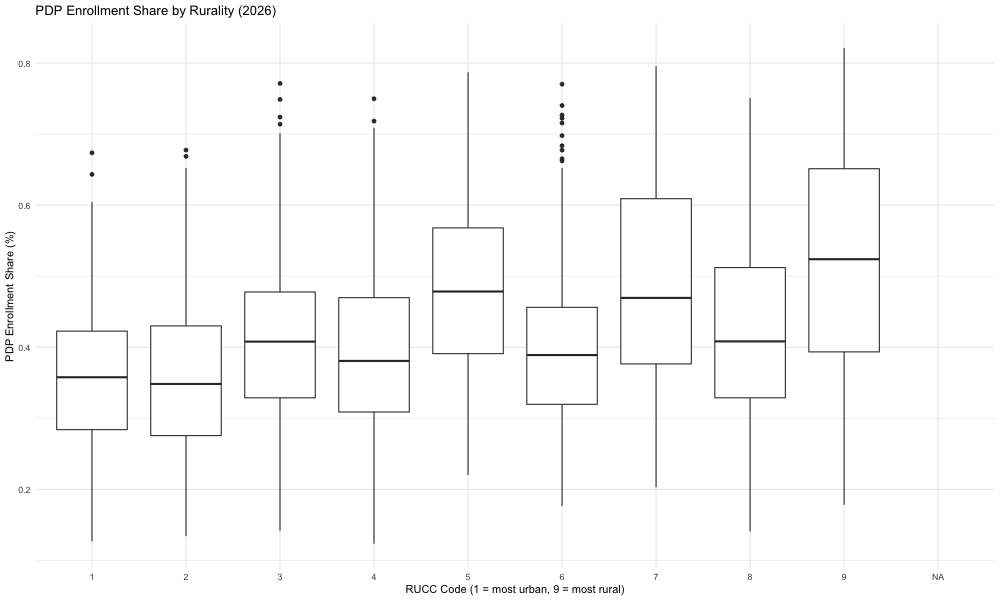

In [ ]:
%%R -i df_enrollment_2026 -w 1000 -h 600

# Visualizing this phenomenon visually
library(tidyverse)  

df_enrollment_2026$Value <- as.numeric(df_enrollment_2026$Value)
ggplot(df_enrollment_2026, aes(x = factor(Value), y = share_of_pdp_enrollment)) +
      geom_boxplot() +
      theme_minimal() +
      labs(x = "RUCC Code (1 = most urban, 9 = most rural)",
           y = "PDP Enrollment Share (%)",
           title = "PDP Enrollment Share by Rurality (2026)")

In [42]:
%%R -i df_enrollment_2026

df_enrollment_2026$Value <- as.numeric(df_enrollment_2026$Value) 
model_5 <- lm(share_of_pdp_enrollment ~ Value + lis_share_total_medicare, data=df_enrollment_2026)
summary(model_5)


Call:
lm(formula = share_of_pdp_enrollment ~ Value + lis_share_total_medicare, 
    data = df_enrollment_2026)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.35057 -0.07964 -0.00350  0.07646  0.38730 

Coefficients:
                           Estimate Std. Error t value Pr(>|t|)    
(Intercept)               0.4261667  0.0052348   81.41   <2e-16 ***
Value                     0.0182975  0.0007312   25.02   <2e-16 ***
lis_share_total_medicare -4.3434830  0.1620733  -26.80   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.1141 on 3009 degrees of freedom
  (210 observations deleted due to missingness)
Multiple R-squared:  0.2736,	Adjusted R-squared:  0.2731 
F-statistic: 566.7 on 2 and 3009 DF,  p-value: < 2.2e-16



Together, LIS enrollment and rural/urban distinction have the strongest predictive power of the PDP enrollment share among the Medicare beneficiaries, explaining 27% of its variation. Controlling for rurality, the effect of LIS enrollment share became stronger. 